<a href="https://colab.research.google.com/github/mbmanoj904-hue/Generative-ai/blob/main/GAN_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install tensorflow matplotlib

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20 | Generator Loss: 0.7256 | Discriminator Loss: 1.1031


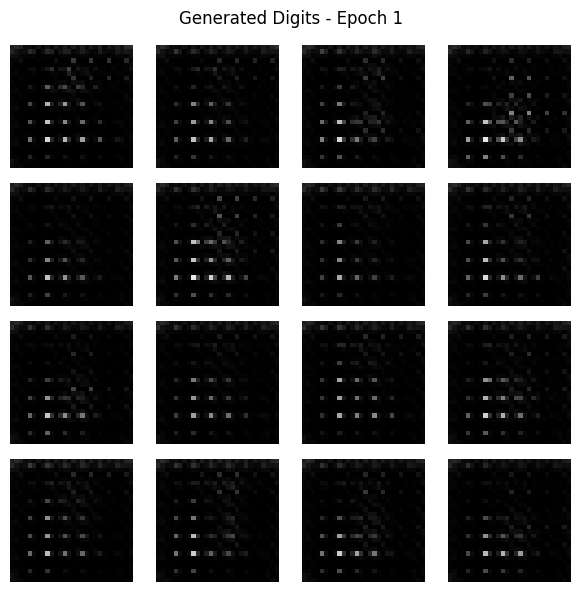

Epoch 2/20 | Generator Loss: 0.8703 | Discriminator Loss: 1.2449


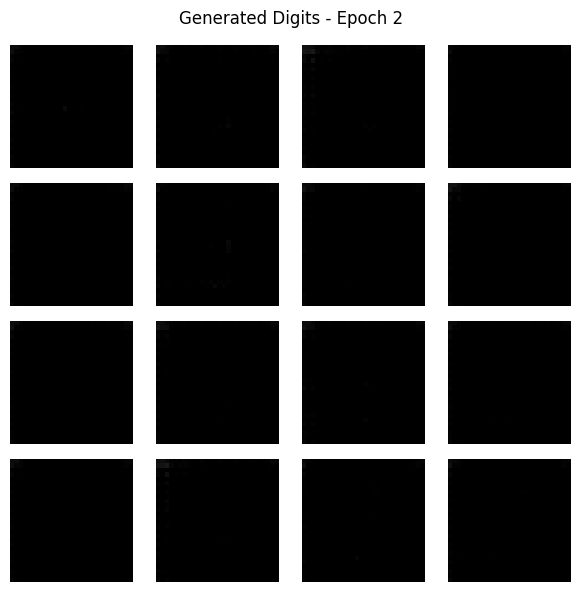

Epoch 3/20 | Generator Loss: 1.0785 | Discriminator Loss: 0.9985


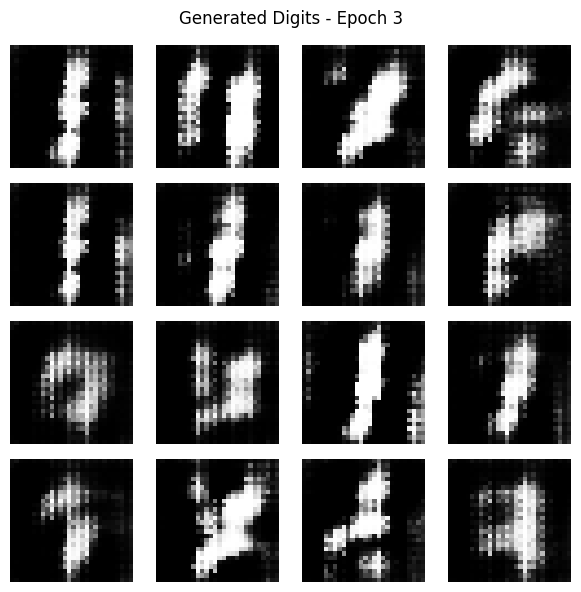

Epoch 4/20 | Generator Loss: 0.8108 | Discriminator Loss: 1.3389


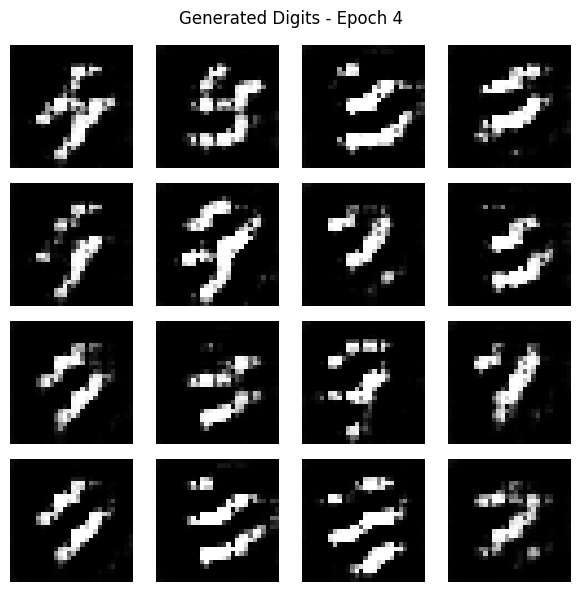

Epoch 5/20 | Generator Loss: 0.8664 | Discriminator Loss: 1.2628


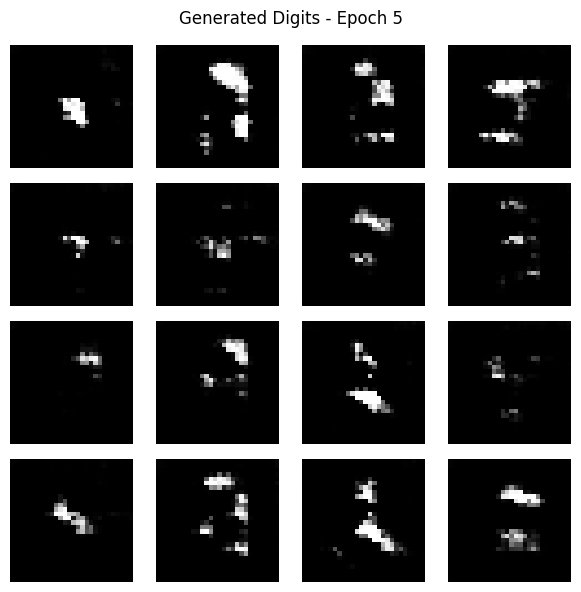

Epoch 6/20 | Generator Loss: 0.8289 | Discriminator Loss: 1.3190


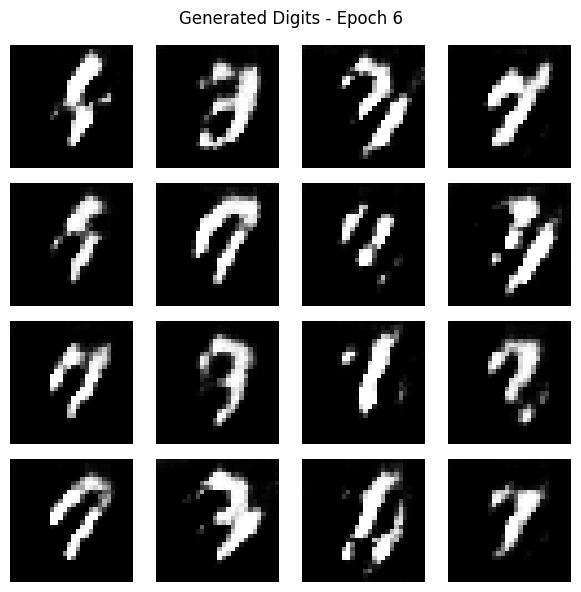

Epoch 7/20 | Generator Loss: 0.8521 | Discriminator Loss: 1.2682


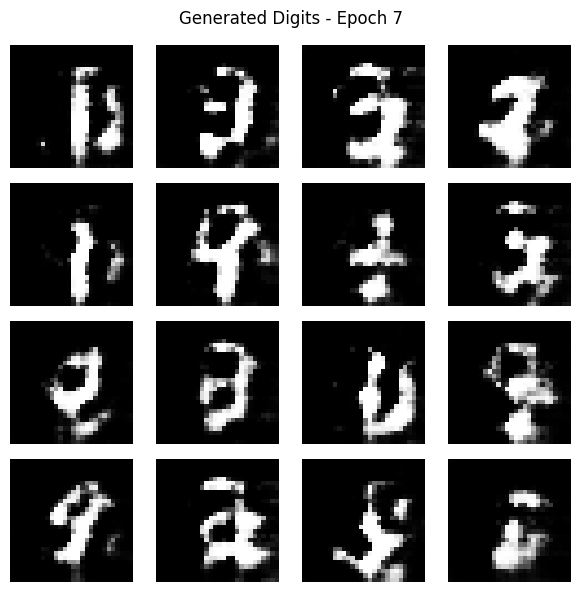

Epoch 8/20 | Generator Loss: 0.8100 | Discriminator Loss: 1.3172


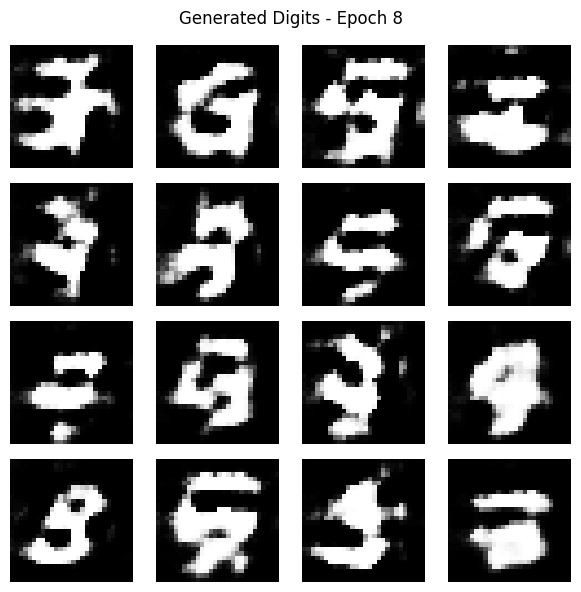

Epoch 9/20 | Generator Loss: 0.9148 | Discriminator Loss: 1.2377


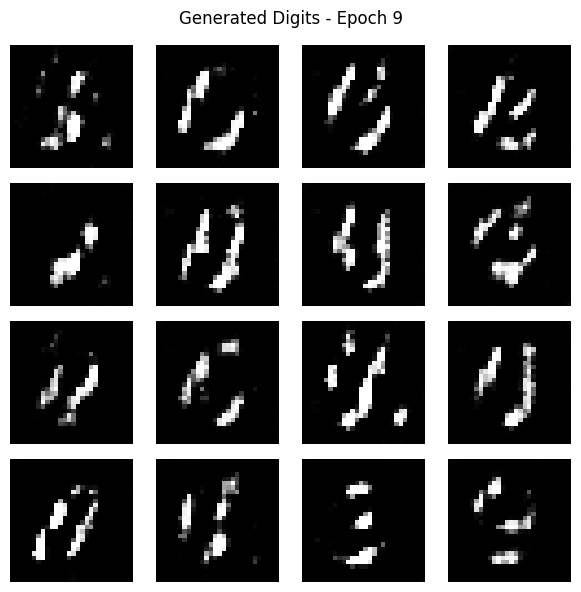

Epoch 10/20 | Generator Loss: 0.9011 | Discriminator Loss: 1.2284


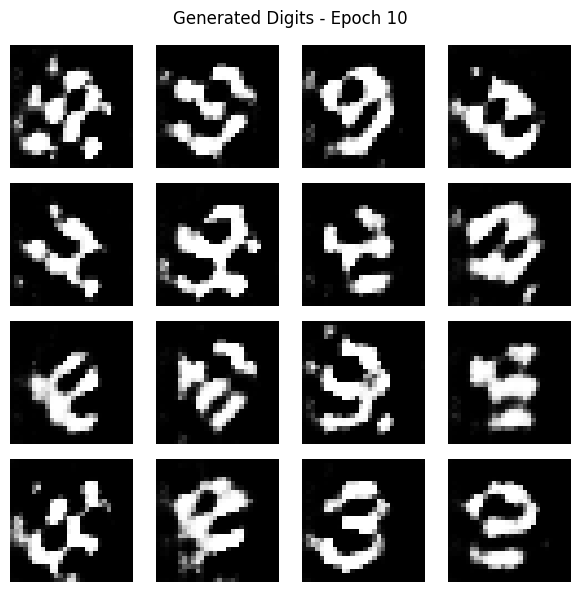

Epoch 11/20 | Generator Loss: 1.0078 | Discriminator Loss: 1.1345


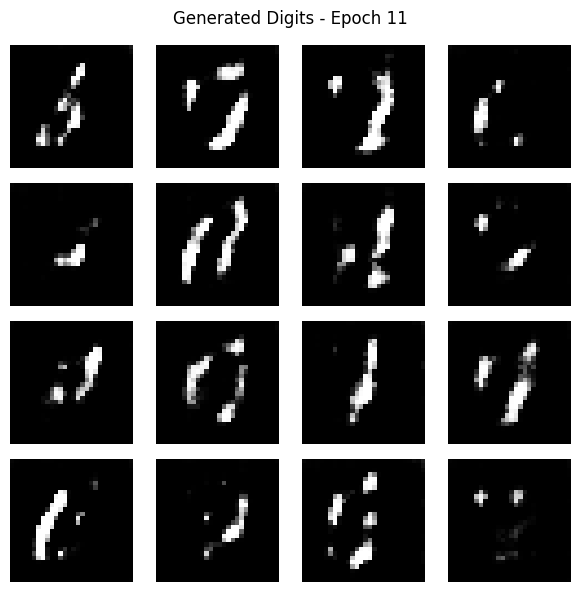

Epoch 12/20 | Generator Loss: 1.0103 | Discriminator Loss: 1.1484


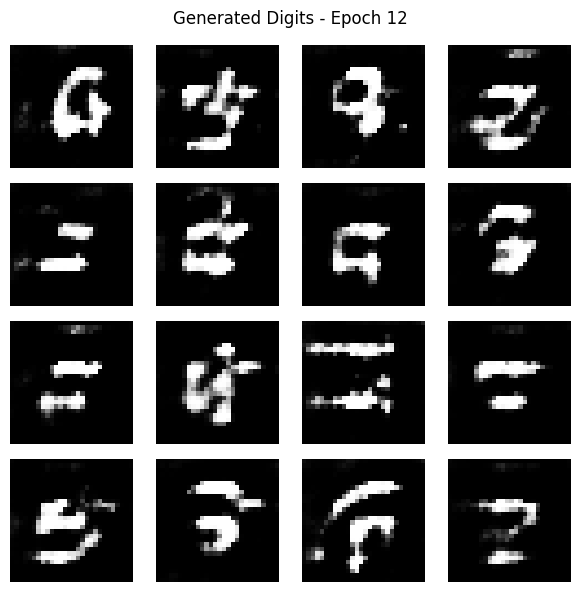

Epoch 13/20 | Generator Loss: 1.0201 | Discriminator Loss: 1.1495


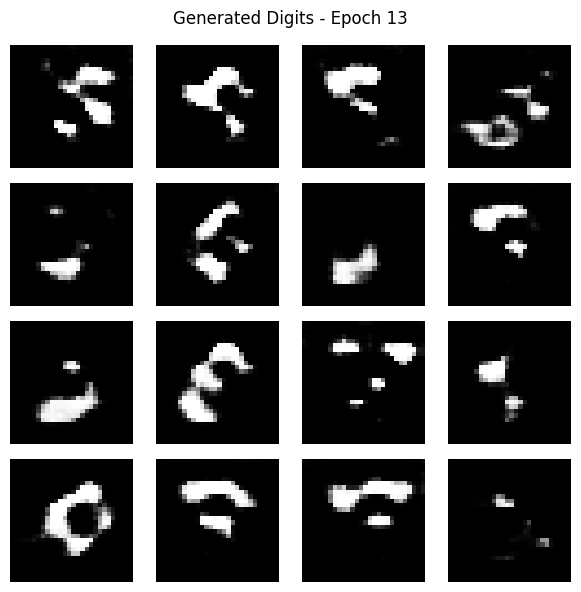

Epoch 14/20 | Generator Loss: 1.0262 | Discriminator Loss: 1.1509


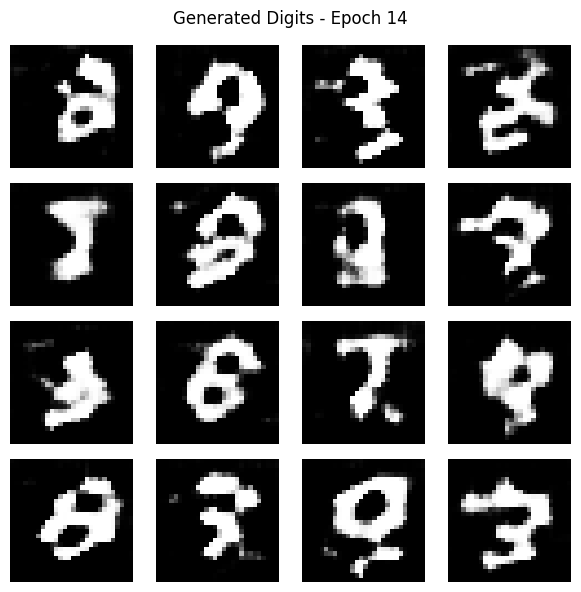

Epoch 15/20 | Generator Loss: 1.1088 | Discriminator Loss: 1.1286


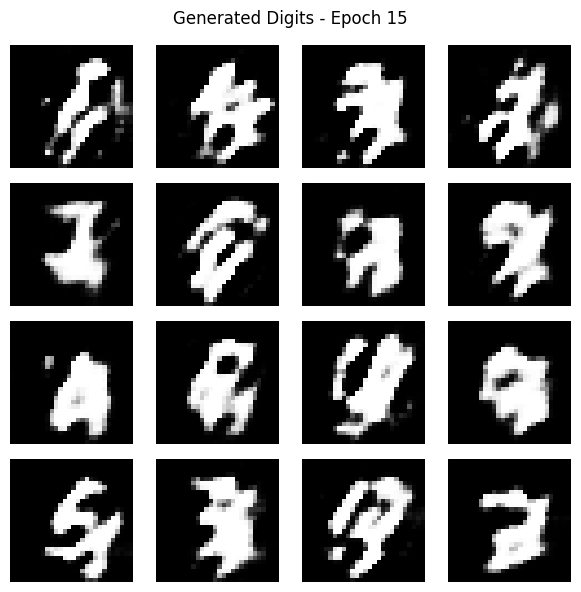

Epoch 16/20 | Generator Loss: 1.2005 | Discriminator Loss: 1.0438


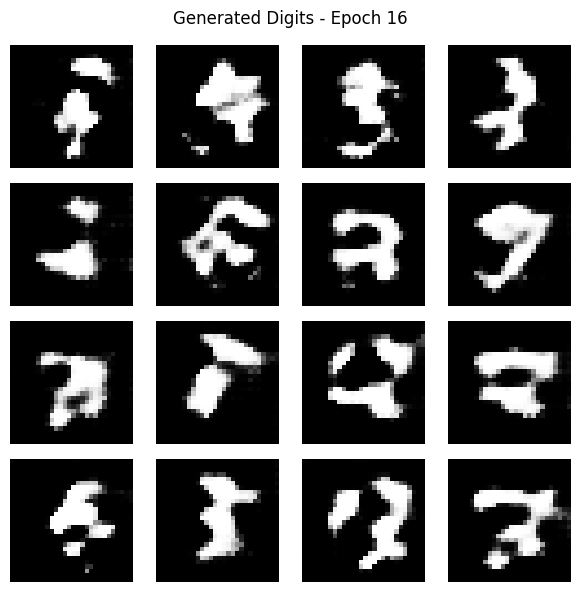

Epoch 17/20 | Generator Loss: 1.1226 | Discriminator Loss: 1.0800


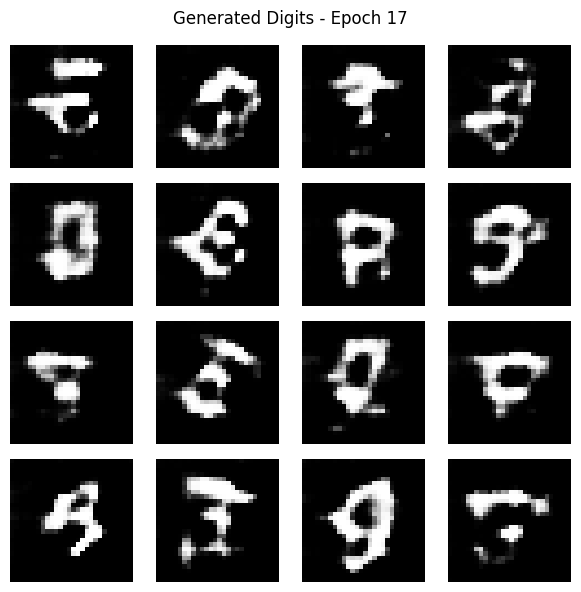

Epoch 18/20 | Generator Loss: 1.1225 | Discriminator Loss: 1.0779


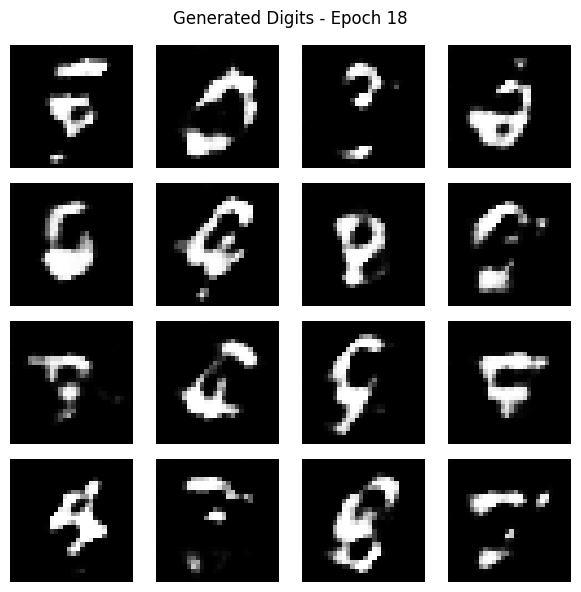

Epoch 19/20 | Generator Loss: 1.0934 | Discriminator Loss: 1.1186


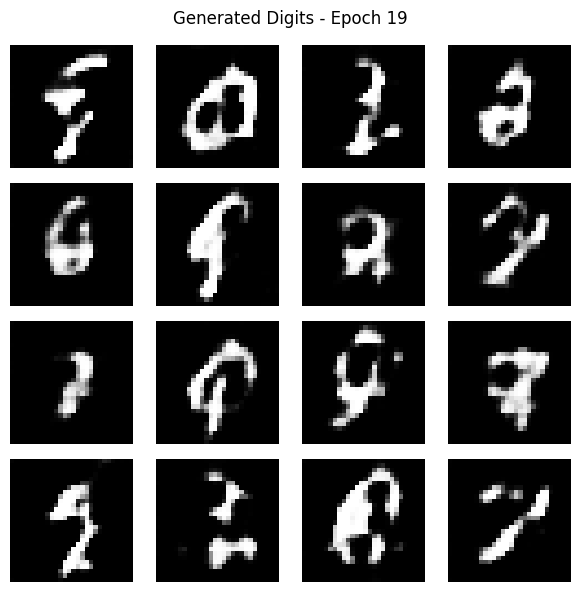

Epoch 20/20 | Generator Loss: 1.2177 | Discriminator Loss: 1.0633


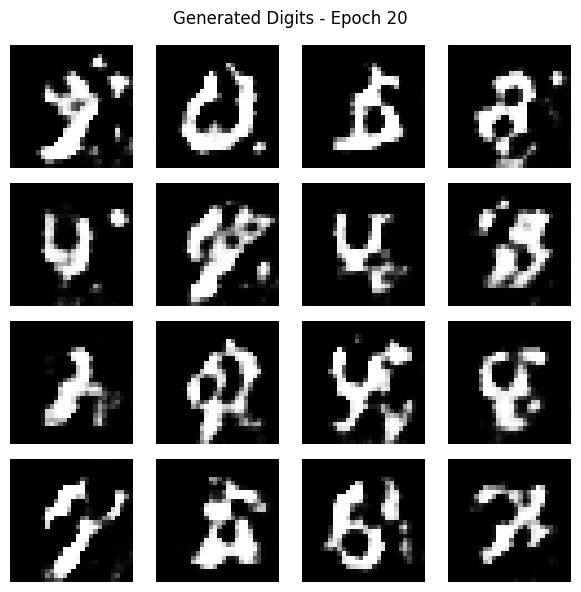

Training completed successfully!


In [1]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

# Project: Handwritten Digit Generation using DCGAN

# Configuration
BUFFER_SIZE = 60000
BATCH_SIZE = 256
NOISE_DIM = 100
EPOCHS = 20

os.makedirs("outputs", exist_ok=True)

# 1. Load MNIST dataset
(train_images, _), (_, _) = tf.keras.datasets.mnist.load_data()

train_images = train_images.reshape(
    train_images.shape[0], 28, 28, 1
).astype("float32")

# Normalize pixel values to [-1, 1]
train_images = (train_images - 127.5) / 127.5

dataset = tf.data.Dataset.from_tensor_slices(train_images)
dataset = dataset.shuffle(BUFFER_SIZE).batch(
    BATCH_SIZE, drop_remainder=True
)

# 2. Build Generator
def build_generator():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(NOISE_DIM,)),
        tf.keras.layers.Dense(7 * 7 * 256, use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Reshape((7, 7, 256)),

        tf.keras.layers.Conv2DTranspose(
            128, 5, strides=1, padding="same", use_bias=False
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Conv2DTranspose(
            64, 5, strides=2, padding="same", use_bias=False
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Conv2DTranspose(
            1, 5, strides=2, padding="same",
            use_bias=False, activation="tanh"
        )
    ], name="Generator")

    return model


# 3. Build Discriminator
def build_discriminator():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1)),

        tf.keras.layers.Conv2D(
            64, 5, strides=2, padding="same"
        ),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Conv2D(
            128, 5, strides=2, padding="same"
        ),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1)
    ], name="Discriminator")

    return model


generator = build_generator()
discriminator = build_discriminator()

# 4. Loss functions and optimizers
cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)


def generator_loss(fake_output):
    return cross_entropy(
        tf.ones_like(fake_output), fake_output
    )


def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(
        tf.ones_like(real_output), real_output
    )
    fake_loss = cross_entropy(
        tf.zeros_like(fake_output), fake_output
    )
    return real_loss + fake_loss


# 5. Training function
@tf.function
def train_step(real_images):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

    with tf.GradientTape() as gen_tape, \
         tf.GradientTape() as disc_tape:

        generated_images = generator(noise, training=True)

        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(
            generated_images, training=True
        )

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(
            real_output, fake_output
        )

    gen_gradients = gen_tape.gradient(
        gen_loss, generator.trainable_variables
    )

    disc_gradients = disc_tape.gradient(
        disc_loss, discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(gen_gradients, generator.trainable_variables)
    )

    discriminator_optimizer.apply_gradients(
        zip(disc_gradients, discriminator.trainable_variables)
    )

    return gen_loss, disc_loss


# 6. Generate and display digit images
seed = tf.random.normal([16, NOISE_DIM])


def generate_images(epoch):
    predictions = generator(seed, training=False)

    fig = plt.figure(figsize=(6, 6))

    for i in range(16):
        plt.subplot(4, 4, i + 1)

        image = (
            predictions[i, :, :, 0] * 127.5 + 127.5
        ).numpy()

        plt.imshow(image, cmap="gray", vmin=0, vmax=255)
        plt.axis("off")

    plt.suptitle(f"Generated Digits - Epoch {epoch}")
    plt.tight_layout()

    filename = f"outputs/epoch_{epoch:03d}.png"
    plt.savefig(filename)
    plt.show()
    plt.close(fig)


# 7. Train the GAN
def train(dataset, epochs):
    for epoch in range(1, epochs + 1):
        gen_metric = tf.keras.metrics.Mean()
        disc_metric = tf.keras.metrics.Mean()

        for images in dataset:
            gen_loss, disc_loss = train_step(images)
            gen_metric.update_state(gen_loss)
            disc_metric.update_state(disc_loss)

        print(
            f"Epoch {epoch}/{epochs} | "
            f"Generator Loss: {gen_metric.result():.4f} | "
            f"Discriminator Loss: {disc_metric.result():.4f}"
        )

        generate_images(epoch)

    generator.save("outputs/generator.keras")
    discriminator.save("outputs/discriminator.keras")

    print("Training completed successfully!")


# 8. Start the project
train(dataset, EPOCHS)